In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import src.assumptions as A
from src.units import Units as U
from src.data.renewable_capacity_factors import (
    get_ninja_2025_capacity_factors,
    get_renewable_capacity_factors,
)
import src.matplotlib_style  # applies project style

# --- Parameters (adjustable) ---
source = "era5_2024"  # "renewable_ninja", "era5_2021", "era5_2024", or "ninja_2025"
country = "UK"              # ERA5 supports many countries; RN is UK-only
resample = "D"              # "h" for hourly if available, "D" for daily
threshold = 0.10            # combined CF threshold
min_duration_days = 1     # min run length (days at daily res) (hour at hourly res)
restrict_to_winter = True
winter_months = {10, 11, 12, 1, 2, 3}
year_to_plot = None         # e.g. 2010, or None for full span
ninja_2025_onshore_region = "NATIONAL" # add in weights
ninja_2025_offshore_region = "NATIONAL" # add in weights
# --- Load capacity factors ---
if source == "ninja_2025":
    cf = get_ninja_2025_capacity_factors(
        resample=resample,
        onshore_region_code=ninja_2025_onshore_region,
        offshore_region_code=ninja_2025_offshore_region,
    )
else:
    cf = get_renewable_capacity_factors(source=source, country=country, resample=resample)
# Columns are:
# - RN: "solar", "wind"
# - ERA5/ninja_2025: "solar", "onshore", "offshore"
# Convert to plain floats for plotting/logic
cf_float = cf.astype(float)



In [2]:
# --- Build combined CF series and detect Dunkelflaute periods ---
solar_weight = float(A.Renewables.CapacityRatios.Solar)
onshore_weight = float(A.Renewables.CapacityRatios.OnshoreWind)
offshore_weight = float(A.Renewables.CapacityRatios.OffshoreWind)

if "wind" in cf_float.columns:
    wind_mix = {"wind": onshore_weight + offshore_weight}
else:
    wind_mix = {
        name: weight
        for name, weight in (("onshore", onshore_weight), ("offshore", offshore_weight))
        if name in cf_float.columns
    }
wind_weight = sum(wind_mix.values())

wind_series_full = sum(weight * cf_float[col] for col, weight in wind_mix.items()) / wind_weight
combined_cf_full = (
    solar_weight * cf_float["solar"]
    + sum(weight * cf_float[col] for col, weight in wind_mix.items())
) / (solar_weight + wind_weight)

to_plot = pd.DataFrame({"solar": cf_float["solar"], "wind": wind_series_full, "combined": combined_cf_full})
if year_to_plot is not None:
    to_plot = to_plot[to_plot.index.year == year_to_plot]
wind_series = to_plot["wind"]

low_cf = combined_cf_full < threshold
if restrict_to_winter:
    low_cf &= combined_cf_full.index.month.isin(winter_months)

events_buffer = []
event_start = None
last_idx = None
length = 0
for timestamp, is_low in low_cf.items():
    if is_low:
        if event_start is None:
            event_start = timestamp
            length = 1
        else:
            length += 1
        last_idx = timestamp
        continue
    if event_start is not None and length >= min_duration_days:
        events_buffer.append({"start": event_start, "end": last_idx, "length": length})
    event_start = None
    last_idx = None
    length = 0

if event_start is not None and length >= min_duration_days:
    events_buffer.append({"start": event_start, "end": last_idx, "length": length})

events = pd.DataFrame(events_buffer)
print(f"Detected {len(events)} Dunkelflaute events (threshold={threshold}, "
      f"min_days={min_duration_days}, winter_only={restrict_to_winter}).")
display(events.sort_values("length", ascending=False).head(20))


Detected 32 Dunkelflaute events (threshold=0.1, min_days=1, winter_only=True).


,start,end,length
13,1969-10-20,1969-10-21,2
15,1972-01-04,1972-01-05,2
18,1974-10-15,1974-10-16,2
26,2004-02-14,2004-02-15,2
20,1975-10-16,1975-10-17,2
22,1987-11-06,1987-11-07,2
17,1974-03-27,1974-03-28,2
0,1940-10-27,1940-10-27,1
7,1951-10-30,1951-10-30,1
6,1947-12-14,1947-12-14,1


C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_32876\29114952.py:65: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


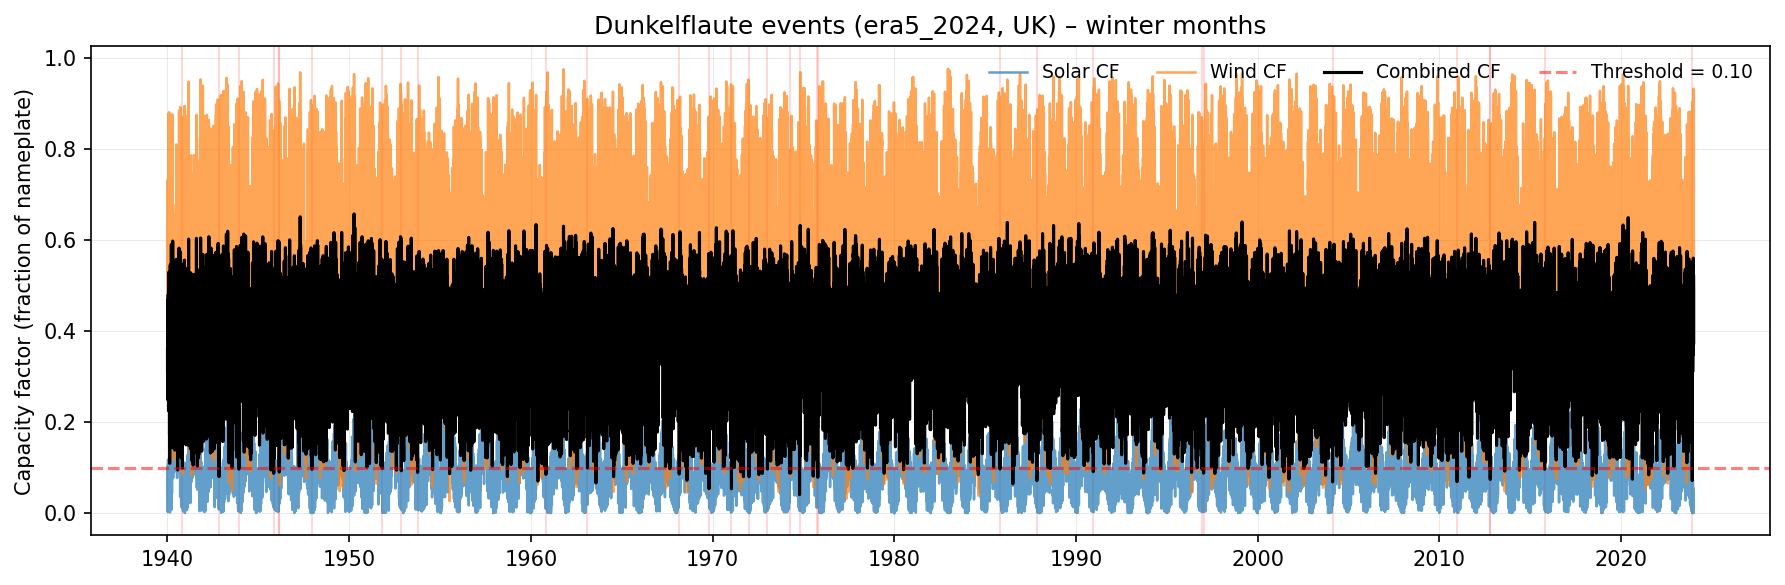

In [3]:
# --- Plotting ---
to_plot = cf_float.copy()
to_plot["combined"] = combined_cf_full

if year_to_plot is not None:
    yr_mask = to_plot.index.year == year_to_plot
    to_plot = to_plot.loc[yr_mask]
    ev_plot = events[
        (events["start"].dt.year == year_to_plot)
        | (events["end"].dt.year == year_to_plot)
    ]
else:
    ev_plot = events

fig, ax = plt.subplots(figsize=(12, 4))

# Plot solar, wind, and combined capacity factors
if "solar" in to_plot.columns:
    ax.plot(
        to_plot.index,
        to_plot["solar"],
        label="Solar CF",
        alpha=0.7,
        lw=1.2,
    )

ax.plot(
    to_plot.index,
    wind_series.loc[to_plot.index],
    label="Wind CF",
    alpha=0.7,
    lw=1.2,
)

ax.plot(
    to_plot.index,
    to_plot["combined"],
    label="Combined CF",
    color="black",
    lw=1.5,
)

# Shade Dunkelflaute intervals
for _, row in ev_plot.iterrows():
    start, end = row["start"], row["end"]
    ax.axvspan(start, end, color="red", alpha=0.15)

ax.axhline(
    threshold,
    color="red",
    ls="--",
    alpha=0.5,
    label=f"Threshold = {threshold:.2f}",
)

ax.set_ylabel("Capacity factor (fraction of nameplate)")
ax.set_title(
    f"Dunkelflaute events ({source}, {country})"
    + (f" – {year_to_plot}" if year_to_plot else "")
    + (" – winter months" if restrict_to_winter else "")
)

ax.legend(loc="upper right", ncol=4, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [4]:
# --- Select the 10 longest events ---
events_longest = events.sort_values("length", ascending=False).head(10)
N = len(events_longest)

if N == 0:
    print("No Dunkelflaute events detected with current parameters.")
else:
    cols = 2
    rows = int(np.ceil(N / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 2.4 * rows), sharey=True)
    axes = np.atleast_1d(axes).ravel()



    for i, (_, e) in enumerate(events_longest.iterrows()):
        ax = axes[i]
        idx = (to_plot.index >= e["start"]) & (to_plot.index <= e["end"])
        t = to_plot.index[idx]

        if "solar" in to_plot.columns:
            ax.plot(t, to_plot.loc[t, "solar"], label="Solar CF", alpha=0.7, lw=1.0)
        ax.plot(t, wind_series.loc[t], label="Wind CF", alpha=0.7, lw=1.0)
        ax.plot(t, to_plot.loc[t, "combined"], label="Combined CF", color="black", lw=1.2)

        ax.axhline(threshold, color="red", ls="--", alpha=0.5)
        # Note: if resample="H", length is hours; adjust label if needed.
        ax.set_title(f'{e["start"].date()} → {e["end"].date()} ({e["length"]})')
        ax.grid(True, alpha=0.3)

    # Format x-axis for daily ticks if daily resampling
    import matplotlib.dates as mdates
    for ax in axes:
        if not ax.has_data():
         continue
        ax.xaxis.set_major_locator(mdates.DayLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))
        ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1))
        ax.tick_params(axis='x', which='minor', length=3, color='gray', labelbottom=False)


    # Turn off any unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    # One shared legend & title
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=9)
    plt.tight_layout()
    plt.show()



Locator attempting to generate 1607 ticks ([-11461.0, ..., -9855.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 38545 ticks ([-11461.0, ..., -9855.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1607 ticks ([-11461.0, ..., -9855.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1607 ticks ([-11461.0, ..., -9855.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 38545 ticks ([-11461.0, ..., -9855.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1607 ticks ([-11461.0, ..., -9855.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1607 ticks ([-11461.0, ..., -9855.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 38545 ticks ([-11461.0, ..., -9855.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1607 ticks ([-11461.0, ..., -9855.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempti

KeyboardInterrupt: 

C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_14924\1497743863.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


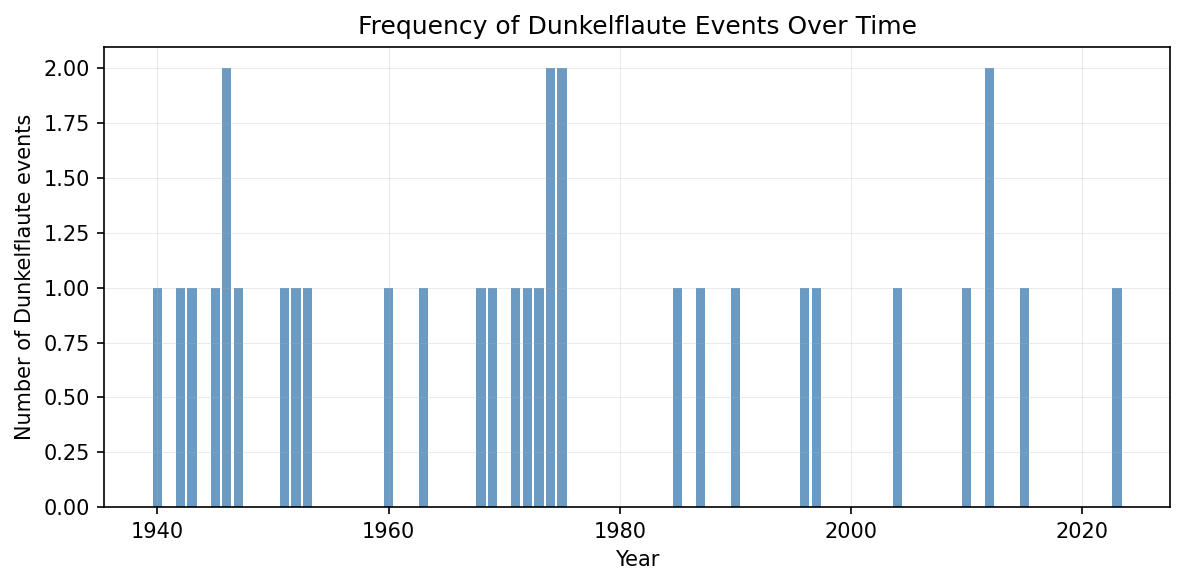

In [ ]:
# --- Analyze frequency of events over time ---
# Convert start time to datetime (if not already)
events["start"] = pd.to_datetime(events["start"])

# Count how many events per year
events["year"] = events["start"].dt.year
yearly_counts = events.groupby("year").size()

# Optional: monthly frequency
# events["month"] = events["start"].dt.to_period("M")
# monthly_counts = events.groupby("month").size()

# --- Plot yearly frequency ---
plt.figure(figsize=(8, 4))
plt.bar(yearly_counts.index, yearly_counts.values, color="steelblue", alpha=0.8)
plt.xlabel("Year")
plt.ylabel("Number of Dunkelflaute events")
plt.title("Frequency of Dunkelflaute Events Over Time")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

